# Titanic - Machine Learning from Disaster

## Exploratory Data Analysis (EDA)

**Author:** Jen Fanen

### Objective

#### The objective of this project is to explore the Titanic dataset, understand passenger characteristics, identify missing values, visualize important patterns, and prepare the data for machine learning.

In [6]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [7]:
# Load the datasets
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [8]:

# Display the first five rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# Shape of the Datasets
print("Training datasets shape:", train.shape)
print("Testing datasets shape:", test.shape)

Training datasets shape: (891, 12)
Testing datasets shape: (418, 11)


### Dataset Shape

The training dataset contains **891 rows (passengers)** and **12 columns (features and target variable)**, while the testing dataset contains **418 rows** and **11 columns (features only)**.

The additional column in the training dataset is **`Survived`**, which is the target variable that the machine learning model will learn to predict. Since the test dataset is used for prediction, it does not include the `Survived` column.

In [10]:
# Display all columns names
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### Dataset Features

The Titanic training dataset contains **12 columns**, each representing a different characteristic of a passenger. These features provide information such as passenger class, age, gender, fare paid, family relationships, cabin number, and embarkation port.

The **`Survived`** column is the target variable that the machine learning model will learn to predict, while the remaining columns are input features used for making predictions.

In [11]:
# Display datasets information
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Dataset Information

The training dataset contains **891 passengers** and **12 columns**. The dataset includes numerical and categorical variables.

From the dataset information, the following observations were made:

- The `Age` column has **177 missing values**.
- The `Cabin` column has **687 missing values**, making it the column with the highest amount of missing data.
- The `Embarked` column has only **2 missing values**.
- Other columns contain complete information.

These missing values will need to be handled during the data cleaning stage before building machine learning models.

In [12]:
# Summary statistics for numerical columns
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Summary Statistics

The `describe()` function provides summary statistics for all numerical variables in the dataset.

### Key Observations

- The dataset contains **891 passengers**, but only **714 age values**, confirming that the `Age` column has missing data.
- The average passenger age is approximately **29.7 years**, while the youngest passenger was **0.42 years** old and the oldest was **80 years** old.
- The average ticket fare was **32.20**, with fares ranging from **0.00** to **512.33**, indicating a wide variation in ticket prices.
- Most passengers travelled in **Third Class (Pclass = 3)**, as shown by the median value of the `Pclass` column.
- Most passengers travelled alone or with a small family, since the median values of `SibSp` and `Parch` are both **0**.
- The summary statistics suggest that some variables, particularly `Fare`, may contain extreme values (outliers), which should be investigated further during the exploratory data analysis.

In [13]:
# Count the number of passengers who survived and those who did not
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

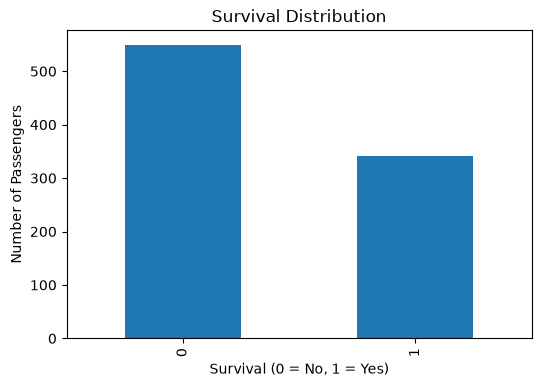

In [14]:
# Visualize the survival distribution
train["Survived"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Survival Distribution"
)

plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

In [15]:
# Calculate survival percentages
survival_percentage = train["Survived"].value_counts(normalize=True) * 100

print(survival_percentage)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


## Survival Distribution

The survival distribution shows that **549 passengers (61.62%) did not survive**, while **342 passengers (38.38%) survived** the Titanic disaster.

This indicates that the majority of passengers did not survive. Since the target variable is imbalanced, it is important to evaluate machine learning models carefully using appropriate performance metrics rather than relying solely on accuracy.

In [16]:
# Count male and female passengers
train["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

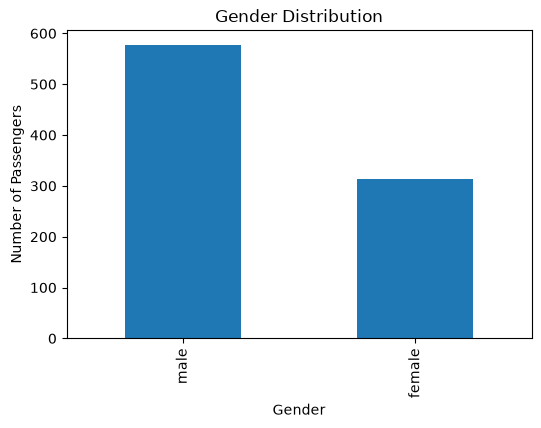

In [17]:
# Plot gender distribution
train["Sex"].value_counts().plot(
    kind="bar",
    figsize=(6, 4),
    title="Gender Distribution"
)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

In [18]:
# Survival rate by gender
train.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Gender Distribution and Survival Analysis

The dataset contains **577 male passengers** and **314 female passengers**, indicating that males made up the majority of passengers aboard the Titanic.

However, the survival rates reveal a significant difference between males and females:

- **Female survival rate:** 74.20%
- **Male survival rate:** 18.89%

This indicates that female passengers were much more likely to survive than male passengers. Gender appears to be one of the strongest predictors of survival and is expected to be an important feature in the machine learning model.

In [19]:
# Count passengers in each passenger class
train["Pclass"].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

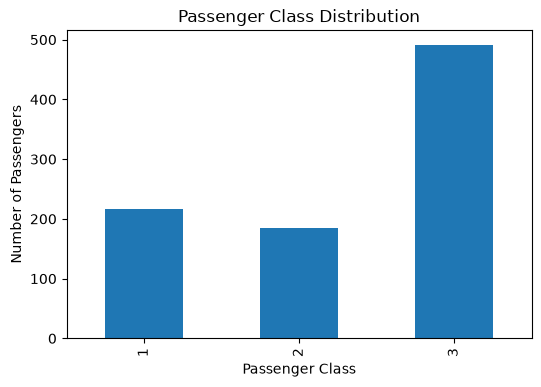

In [20]:
# Visualize passenger class distribution
train["Pclass"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4),
    title="Passenger Class Distribution"
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

In [21]:
# Calculate survival rate by passenger class
train.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Passenger Class Distribution and Survival Analysis

The passenger class distribution shows that the majority of passengers travelled in **Third Class**, followed by **First Class**, while **Second Class** had the fewest passengers.

The survival rates by passenger class were:

- **First Class:** 62.96%
- **Second Class:** 47.28%
- **Third Class:** 24.24%

These results indicate that passengers travelling in **First Class** had the highest chance of survival, while those in **Third Class** had the lowest survival rate. This suggests that passenger class was an important factor influencing survival and is likely to be a significant feature in the machine learning model.

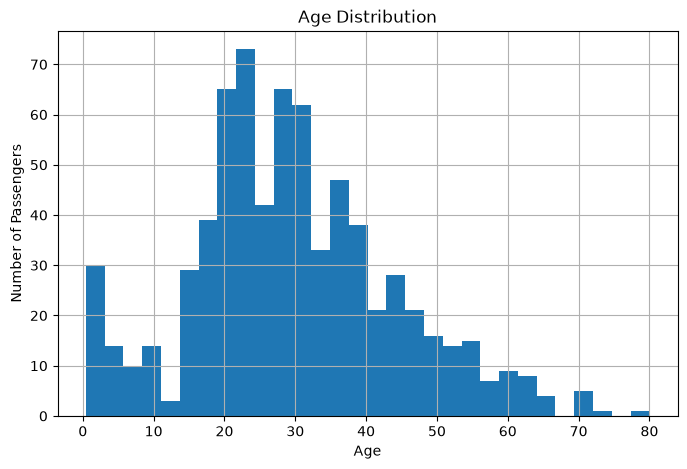

In [22]:
# Plot the distribution of passenger ages
plt.figure(figsize=(8, 5))

train["Age"].hist(bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [23]:
# Summary statistics for Age
train["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [24]:
# Compare average age of survivors and non-survivors
train.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

## Age Distribution and Survival Analysis

The age distribution shows that most passengers were **young adults**, with the highest concentration between **20 and 40 years** of age.

The summary statistics indicate:

- The average passenger age was approximately **29.7 years**.
- The youngest passenger was **0.42 years** old.
- The oldest passenger was **80 years** old.
- Half of the passengers were younger than **28 years** (median age).

Comparing the average ages of survivors and non-survivors:

- Average age of survivors: **28.34 years**
- Average age of non-survivors: **30.63 years**

This suggests that survivors were slightly younger on average, although the difference is relatively small. Additional analysis using age groups may provide more insight into how age influenced survival.